# Question 1

# Question 2

In [3]:
def sigmoid(y_output):
    return 1 / (1 + np.exp(-y_output))

In [21]:
def neuron_state(x, w, b, threshold=0.5):
    """Return neuron status"""



    return {
"weighted_sum": x@w + b,
"probability": sigmoid(x@w + b),
"threshold": threshold,
"predicted_class": np.where(x>=threshold,1,0),
"decision": np.where(np.where(x>=threshold,1,0) == 1,"PASS","FAIL")
}

In [22]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([
0.8, # Study Hours
0.9, # Attendance
0.4 # Missed Assignments
])
w = np.array([
1.2,
0.6,
-1.5
])

b= -0.5
y_hat = x*w + b
z = sigmoid(y_hat)
neuron_status = neuron_state(x, w, b,threshold=0.5)
prediction = np.where(z>=0.5,1,0)

In [23]:
bias_values = [-1.5, -0.5, 0.5]
neuron_f_list = []
for bias in bias_values:
    neuron_f_list.append(neuron_state(x,w,bias,threshold=0.5))



In [24]:
import pandas as pd

neuron_df= pd.DataFrame(neuron_f_list)
neuron_df.index.name = "bias"
neuron_df

,weighted_sum,probability,threshold,predicted_class,decision
bias,,,,,
0,-0.6,0.354344,0.5,"[1, 1, 0]","[PASS, PASS, FAIL]"
1,0.4,0.598688,0.5,"[1, 1, 0]","[PASS, PASS, FAIL]"
2,1.4,0.802184,0.5,"[1, 1, 0]","[PASS, PASS, FAIL]"


# Question 3

In [25]:
# Q 3

import pandas as pd
import numpy as np


def binary_cross_entropy(y, p):
    epsilon = 1e-12
    # برای جلوگیری از(0)log
    p = np.clip(p, epsilon, 1 - epsilon)

    l = -(y * np.log(p) + (1 - y) * np.log(1 - p))
    return l



def mse_loss(y, p):
    return (y - p) ** 2


y_true = np.array([1, 1, 0, 0])
y_pred = np.array([0.95, 0.55, 0.05, 0.90])


a = binary_cross_entropy(1, 0.95)
b = binary_cross_entropy(1, 0.55)
c = binary_cross_entropy(0, 0.05)
d = binary_cross_entropy(0, 0.90)

df = pd.DataFrame({"loss": [a, b, c, d], "MSE": mse_loss(y_true, y_pred), "probability": [0.95, 0.55, 0.05, 0.90], "class": [1, 1, 0, 0]}, index=["a", "b", "c", "d"])
df.sort_values("loss")


def dataset_bce(y_true, y_pred):
    return np.mean(binary_cross_entropy(y_true, y_pred))


dataset_bce(y_true, y_pred)

np.float64(0.7507521706311919)

# Question 4

In [ ]:
# decision boundry equation is X@W + b = 0
#in 1D data Decision boundry is a point
#in 2D data Decision boundry is a line
# in 3D data Decision boundry is a plane
# in ND data Decision boundry is a hyperplane

# when features multiply with W vector the line that made by this equation X@W+b gonna change the direction of the line or hyper plane...
# Bias can shift the decision boundry or in the other words change the starting point where the X = 0


In [ ]:
# A single perceptron only can solve linear separable problems
#if we wanna solve XOR gate problem we need three neuron to solve this problem or three decision boundry
# because a single perceptron can only optimize bias and weights not make a non-linear decision boundry


Output of layer 1: [-3 -1  1  3  5]
Output of layer 2: [ 13   7   1  -5 -11]
if we don't put a non-linear activation function between neurons even a million perceptron can't solve a non linear problem
because the outputs are still linaer
neuron2 = W@(W@X+b)+b = W@X+b   


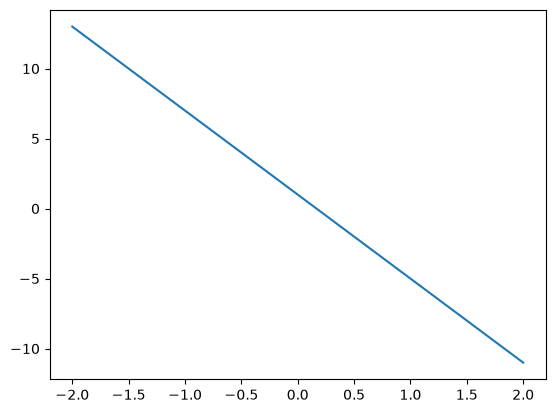

In [14]:
import numpy as np
import matplotlib.pyplot as plt
# first linear layer
def layer_1(x):
    return 2 * x + 1

# second layer
def layer_2(h):
    return -3 * h + 4


x = np.array([-2, -1, 0, 1, 2])
output  = layer_2(layer_1(x))
print(f"Output of layer 1: {layer_1(x)}")
print(f"Output of layer 2: {layer_2(layer_1(x))}")
print(f"if we don't put a non-linear activation"
      f" function between neurons even a million"
      f" perceptron can't solve a non linear problem\n"
      f"because the outputs are still linaer\n"
      f"neuron2 = W@(W@X+b)+b = W@X+b   ")
plt.plot(x,output)
plt.show()

Output of layer 1: [0 0 1 3 5]
Output of layer 2: [  4   4   1  -5 -11]


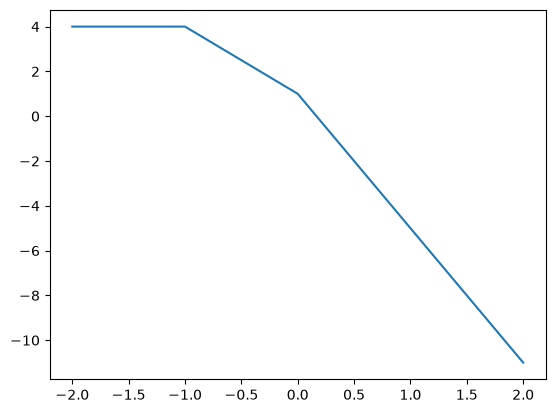

In [15]:
def relu(x):
    return np.where(x<0,0, x)
def layer_1(x):
    return relu(2 * x + 1)
def layer_2(h):
    return -3 * h + 4

x = np.array([-2, -1, 0, 1, 2])
output  = layer_2(layer_1(x))
print(f"Output of layer 1: {layer_1(x)}")
print(f"Output of layer 2: {layer_2(layer_1(x))}")
plt.plot(x,output)
plt.show()

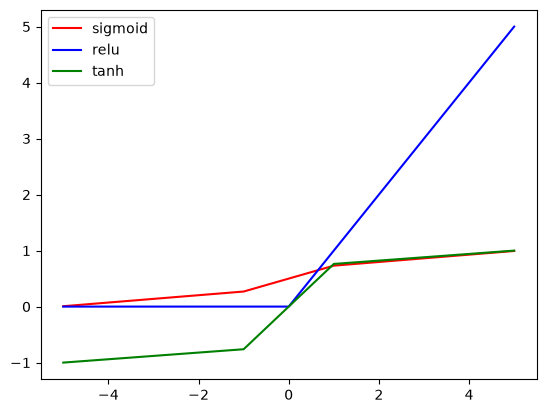

In [21]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
def relu(z):
    return np.where(z<0,0,z)
def tanh_activation(z):
    return np.tanh(z)

z = np.array([-5, -1, 0, 1, 5], dtype=float)

plt.plot(z,sigmoid(z),color="red",label="sigmoid")
plt.plot(z,relu(z),color="blue",label="relu")
plt.plot(z,tanh_activation(z),color="green",label="tanh")
plt.legend()
plt.show()

In [22]:
import pandas as pd
df = pd.DataFrame({
    "sigmoid":sigmoid(z),
    "relu":relu(z),
    "tanh":tanh_activation(z),
},index=z)
df.index.name = "z"
df

,sigmoid,relu,tanh
z,,,
-5.0,0.006693,0.0,-0.999909
-1.0,0.268941,0.0,-0.761594
0.0,0.500000,0.0,0.000000
1.0,0.731059,1.0,0.761594
5.0,0.993307,5.0,0.999909


In [23]:
# binary classification => sigmoid
# multi class => softmax
# regression => linear

# Vanishing Gradient in sigmoid and tanh : this appears when the output is too big or to small
# sigmoid behavior for too small => to zero | sigmoid behavior for too big => to 1
#for tanh this happend for -1 and 1 for too big and too small values
# this make gradient too small and model can't learn
# relu has a different problem because if a neuron output is zero or negative
# relu has no gradient at this point and neuron will stop learning

# GELU usually use for training GPT models
# because RELU solve the vanishing gradient for too big value and this is good for learning
# and sigmoid return probability in binary classification problems and this is good for output on MLP

# Question 5

In [4]:
import numpy as np
W1 = np.array([
[ 0.7, -0.4, 0.8],
[-0.6, 0.9, 0.2]
])
b1 = np.array([0.1, -0.2])
W2 = np.array([1.2, -0.8])
b2 = -0.3


#data
x_A = np.array([0.6, -1.0, 0.8])
x_B = np.array([-0.8, 0.7, -0.3])

print(f"W1.shape = {W1.shape}\nW2.shape = {W2.shape}\nx_A.shape = {x_A.shape}\nx_B.shape = {x_B.shape}")

W1.shape = (2, 3)
W2.shape = (2,)
x_A.shape = (3,)
x_B.shape = (3,)


In [21]:
def relu(z):
    return np.maximum(0, z)

def hidden_layer(x, W, b):
    z = x@ W.T + b
    activation = relu(z)
    return z, activation

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def output_layer(hidden_output, W, b):
    z = hidden_output@W+b
    activation = sigmoid(z)
    return z,activation


In [27]:
def classification_network(
x,
W1,
b1,
W2,
b2,
threshold=0.5
):
    #first layer
    hidden1_output, activation1 = hidden_layer(x, W1, b1)
    #second layer
    hidden2_output, activation2 = output_layer(activation1, W2, b2)

    classification_state = np.where(
        activation2 < 0.30,
        "Confident Class 0",
        np.where(
            activation2 < 0.70,
            "Uncertain",
            "Confident Class 1"
        )
    )
    return{
    "hidden_weighted_sum": hidden1_output,
    "hidden_activation": activation1,
    "output_weighted_sum": hidden2_output,
    "probability_class_1": activation2,
    "threshold": threshold,
    "predicted_class":np.array(activation2 > threshold,dtype=int),
    "classification_state":classification_state

    }



In [29]:
X = np.array([x_A,x_B])
result = classification_network(X,W1,b1,W2,b2)
result

{'hidden_weighted_sum': array([[ 1.56, -1.3 ],
        [-0.98,  0.85]]),
 'hidden_activation': array([[1.56, 0.  ],
        [0.  , 0.85]]),
 'output_weighted_sum': array([ 1.572, -0.98 ]),
 'probability_class_1': array([0.82806854, 0.27289178]),
 'threshold': 0.5,
 'predicted_class': array([1, 0]),
 'classification_state': array(['Confident Class 1', 'Confident Class 0'], dtype='<U17')}

In [33]:
thresholds = [0.3, 0.5, 0.8]

for threshold in thresholds:
    result = classification_network(X,W1,b1,W2,b2,threshold=threshold)
    print(f"{threshold}:\n {result}\n{"-"*30}")

0.3:
 {'hidden_weighted_sum': array([[ 1.56, -1.3 ],
       [-0.98,  0.85]]), 'hidden_activation': array([[1.56, 0.  ],
       [0.  , 0.85]]), 'output_weighted_sum': array([ 1.572, -0.98 ]), 'probability_class_1': array([0.82806854, 0.27289178]), 'threshold': 0.3, 'predicted_class': array([1, 0]), 'classification_state': array(['Confident Class 1', 'Confident Class 0'], dtype='<U17')}
------------------------------
0.5:
 {'hidden_weighted_sum': array([[ 1.56, -1.3 ],
       [-0.98,  0.85]]), 'hidden_activation': array([[1.56, 0.  ],
       [0.  , 0.85]]), 'output_weighted_sum': array([ 1.572, -0.98 ]), 'probability_class_1': array([0.82806854, 0.27289178]), 'threshold': 0.5, 'predicted_class': array([1, 0]), 'classification_state': array(['Confident Class 1', 'Confident Class 0'], dtype='<U17')}
------------------------------
0.8:
 {'hidden_weighted_sum': array([[ 1.56, -1.3 ],
       [-0.98,  0.85]]), 'hidden_activation': array([[1.56, 0.  ],
       [0.  , 0.85]]), 'output_weighted_su

# Question 6

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
data = load_iris()
X = data.data
y = data.target


In [8]:
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2,random_state=10)

model = DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(Xtrain,ytrain)
ypred = model.predict(Xtest)
accuracy = model.score(Xtest,ytest)

print(f"accuracy score test data with out CV : {accuracy:.2f}")

accuracy score test data with out CV : 0.93


In [29]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
import numpy as np
tree = DecisionTreeClassifier()
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
searcher = GridSearchCV(
    cv=skf,
    estimator=tree,
    param_grid={
        "max_depth":[1,3,5,10],
        "random_state":[10,20,30,42,50]
    },
    scoring="accuracy"
)
searcher.fit(Xtrain,ytrain)
best_model = searcher.best_estimator_
# print(f"Best Parameters : {searcher.best_params_}")
# print(f"Best score : {searcher.best_score_}")
split_0score = searcher.cv_results_["split0_test_score"].mean()
split_1score = searcher.cv_results_["split1_test_score"].mean()
split_2score = searcher.cv_results_["split2_test_score"].mean()
split_3score = searcher.cv_results_["split3_test_score"].mean()
split_4score = searcher.cv_results_["split4_test_score"].mean()
mean_acc = searcher.cv_results_["mean_test_score"].mean()
std_acc = searcher.cv_results_["std_test_score"].mean()
std_acc

np.float64(0.0553258856840997)

# Question 7

In [34]:
def step(z):
    return 1 if z >= 0 else 0

def perceptron(x, w, b):
    z = np.dot(w, x) + b
    return step(z)

def network(x):
    # Hidden neuron 1: OR
    h1 = perceptron(x, w=[1, 1], b=-0.5)

    # Hidden neuron 2: NAND
    h2 = perceptron(x, w=[-1, -1], b=1.5)

    # Output neuron: AND(h1, h2)
    output = perceptron(
        x=[h1, h2],
        w=[1, 1],
        b=-1.5
    )

    return output



In [35]:
inputs = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

for x in inputs:
    print(f"{x} -> {network(x)}")

[0, 0] -> 0
[0, 1] -> 1
[1, 0] -> 1
[1, 1] -> 0
